In [1]:
!apt-get install -y fonts-nanum > /dev/null

In [2]:
!pip install torch -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '/content/drive/MyDrive/power_forecast/'

train_df = pd.read_csv(DATA_DIR + 'train_fe.csv')

print('로드 완료')
print('train shape:', train_df.shape)
print('GPU 사용 가능:', torch.cuda.is_available())

Mounted at /content/drive
로드 완료
train shape: (204000, 35)
GPU 사용 가능: True


In [3]:
# LSTM은 sin/cos 없이 시간 순서 자체를 학습
# 트리 모델과 다른 feature 구성 사용
LSTM_FEATURES = [
    '건물번호', 'building_type_enc',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)',
    'has_solar', 'has_ess', 'is_IDC',
    'month', 'day', 'hour', 'weekday', 'is_weekend',
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', 'THI', 'CDH',
    'building_hour_mean', 'building_weekday_mean', 'building_mean',
    '일조(hr)', '일사(MJ/m2)',
]
TARGET    = '전력소비량(kWh)'
SEQ_LEN   = 24  # 과거 24시간을 보고 다음 1시간 예측
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)
    return np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred))) * 100

print(f'사용 디바이스: {DEVICE}')
print(f'시퀀스 길이: {SEQ_LEN}시간')
print(f'feature 수: {len(LSTM_FEATURES)}개')

사용 디바이스: cuda
시퀀스 길이: 24시간
feature 수: 26개


In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, features, target, seq_len):
        self.X = data[features].values.astype(np.float32)
        self.y = data[target].values.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.seq_len]        # (seq_len, feature 수)
        y = self.y[idx + self.seq_len]               # 다음 시간 전력소비량
        return torch.tensor(x), torch.tensor(y)

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True     # (배치, 시퀀스, feature) 순서
        )

        # 출력 레이어: LSTM 결과 → 전력소비량 1개 예측
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # 마지막 시간 스텝의 출력만 사용
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()

In [6]:
def train_lstm_for_building(building_data, features, target,
                             seq_len, epochs=30, lr=0.001):
    # 날짜 기준 분리
    train_data = building_data[building_data['일시'] < '20240818 00']
    val_data   = building_data[building_data['일시'] >= '20240818 00']

    if len(train_data) <= seq_len or len(val_data) <= seq_len:
        return None, None

    # 정규화
    # train 기준으로 min/max 계산 후 val에도 동일하게 적용
    feature_min  = train_data[features].min()
    feature_max  = train_data[features].max()
    feature_range = feature_max - feature_min
    feature_range[feature_range == 0] = 1  # 분모 0 방지

    train_norm = train_data.copy()
    val_norm   = val_data.copy()
    train_norm[features] = (train_data[features] - feature_min) / feature_range
    val_norm[features]   = (val_data[features]   - feature_min) / feature_range

    # target 정규화
    target_min   = train_data[target].min()
    target_range = train_data[target].max() - target_min
    if target_range == 0:
        target_range = 1
    train_norm[target] = (train_data[target] - target_min) / target_range
    val_norm[target]   = (val_data[target]   - target_min) / target_range

    # DataLoader 생성
    train_dataset = TimeSeriesDataset(train_norm, features, target, seq_len)
    val_dataset   = TimeSeriesDataset(val_norm,   features, target, seq_len)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

    # 모델 초기화
    model     = LSTMModel(input_size=len(features)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    # 학습
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        # 학습
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

        # 검증
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                pred     = model(x_batch)
                val_loss += criterion(pred, y_batch).item()

        val_loss /= len(val_loader)

        # 최적 모델 저장
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = model.state_dict().copy()

    # 최적 모델로 예측
    model.load_state_dict(best_model_state)
    model.eval()

    val_preds_norm = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(DEVICE)
            pred    = model(x_batch)
            val_preds_norm.extend(pred.cpu().numpy())

    # 역정규화 (원래 스케일로 복원)
    val_preds = np.array(val_preds_norm) * target_range + target_min
    val_true  = val_data[target].values[seq_len:]

    return val_preds, val_true

In [7]:
# 건물 100개 각각 LSTM 학습

all_preds = []
all_true  = []
failed    = []

for bnum in sorted(train_df['건물번호'].unique()):
    building_data = train_df[train_df['건물번호'] == bnum].copy()
    building_data = building_data.sort_values('일시').reset_index(drop=True)

    preds, true = train_lstm_for_building(
        building_data, LSTM_FEATURES, TARGET, SEQ_LEN
    )

    if preds is None:
        failed.append(bnum)
        continue

    all_preds.extend(preds)
    all_true.extend(true)

    if bnum % 10 == 0:
        print(f'건물 {bnum} 완료 ({bnum}/100)')

score_lstm = smape(np.array(all_true), np.array(all_preds))

print(f'\n전체 {100 - len(failed)}개 건물 학습 완료')
if failed:
    print(f'실패한 건물: {failed}')
print(f'LSTM Validation SMAPE: {score_lstm:.4f}')

건물 10 완료 (10/100)
건물 20 완료 (20/100)
건물 30 완료 (30/100)
건물 40 완료 (40/100)
건물 50 완료 (50/100)
건물 60 완료 (60/100)
건물 70 완료 (70/100)
건물 80 완료 (80/100)
건물 90 완료 (90/100)
건물 100 완료 (100/100)

전체 100개 건물 학습 완료
LSTM Validation SMAPE: 9.0628


=== 트리 모델 vs LSTM 비교 ===
XGBoost 유형별 (실험 4) : 6.8899
앙상블          (실험 7) : 6.7324
LSTM            (실험 8) : 9.0628



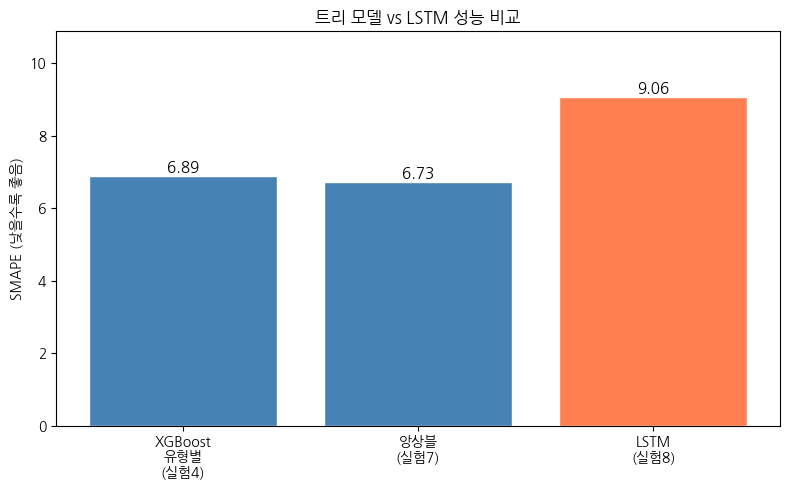

In [8]:
result_path     = DATA_DIR + 'experiment_results.csv'
existing_results = pd.read_csv(result_path)
score_exp4      = existing_results[existing_results['실험번호'] == 4]['SMAPE'].values[0]
score_exp7      = existing_results[existing_results['실험번호'] == 7]['SMAPE'].values[0]

print('=== 트리 모델 vs LSTM 비교 ===')
print(f'XGBoost 유형별 (실험 4) : {score_exp4:.4f}')
print(f'앙상블          (실험 7) : {score_exp7:.4f}')
print(f'LSTM            (실험 8) : {score_lstm:.4f}')
print()

# 시각화
labels = ['XGBoost\n유형별\n(실험4)', '앙상블\n(실험7)', 'LSTM\n(실험8)']
scores = [score_exp4, score_exp7, score_lstm]
colors = ['steelblue', 'steelblue', 'coral']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color=colors, edgecolor='white')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.title('트리 모델 vs LSTM 성능 비교')
plt.ylabel('SMAPE (낮을수록 좋음)')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()

In [9]:
new_result = pd.DataFrame([{
    '실험번호': 8,
    '실험명': 'LSTM_건물별',
    'SMAPE': score_lstm,
    '개선폭': score_exp7 - score_lstm,
    '비고': f'SEQ_LEN={SEQ_LEN}, hidden=64, layers=2, epochs=30'
}])

combined = pd.concat([existing_results, new_result], ignore_index=True)
combined = combined.drop_duplicates(subset='실험번호', keep='last')
combined = combined.sort_values('실험번호').reset_index(drop=True)
combined.to_csv(result_path, index=False)

print('실험 8 결과 저장 완료')
print(combined.to_string(index=False))

실험 8 결과 저장 완료
 실험번호                 실험명     SMAPE       개선폭                                                                                         비고
    0 대회_Baseline_XGBoost 24.014000  0.000000                                                     대회 제공 Baseline, Feature Engineering 없음
    1          FE_XGBoost  8.424200 15.589800                                                                  Feature Engineering 추가 효과
    2         LightGBM_전체  9.388100 -0.963900                                                                            XGBoost보다 성능 낮음
    3         유형별_XGBoost  7.257900  2.130200                                                                            유형별 모델 분리 효과 확인
    4      유형별_XGBoost_튜닝  6.889891  0.368009 최적파라미터: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9, 'colsample_bytree': 0.9}
    5      건물별_XGBoost_튜닝  7.029944 -0.140053                                                                        100개 건물 각각 개별 모델 학습
    7            Ensemble  